# 🔬 Lab 04 — Malware Detection from API Call Sequences
**Home Assignment — Models for AI, Politecnico di Torino**

In this lab you will tackle a **cybersecurity** problem: detecting whether a Windows executable is malicious by analysing the sequence of **system API calls** it makes at runtime.

Malware often exhibits characteristic behavioural patterns in the API calls it invokes (e.g., loading DLLs, writing to foreign process memory, opening network sockets). 

Your task is to **build classifiers that distinguish malware from benign software** based solely on these sequences.

**How to use this notebook:**
- Red text marks your tasks - complete each cell before moving on.
- You may (and should) refer to the three previous labs.
- You are provided with a `train.json` and a `test.json` files.

## 🕵🏻 Valutazione 

- **Quando**: L’esercitazione dovrà essere consegnata tramite il portale della didattica entro domenica 5 aprile 2026. 
 
- **Come**: Le risposte dovranno essere inserite direttamente nel notebook Jupyter in cui sono presenti le domande, riportando sia il codice sia le risposte e i risultati (se necessari). Il file dovrà essere esportato e consegnato esclusivamente in formato HTML, nominato nel seguente modo: `<matricola>.html`
 
- **Valutazione**: La valutazione terrà conto della correttezza della metodologia applicata, della chiarezza e coerenza delle risposte fornite, nonché dell’eventuale adeguata giustificazione delle scelte effettuate.

## Objectives of the lab

To complete the lab assignment, the student will:

1. **Characterise** a dataset of categorical sequence data and reason about its challenges (class imbalance, vocabulary coverage, variable lengths).
2. **Build a Shallow Learning Baseline** with a Random Forest — connecting to Lab 01.
3. **Use learned embeddings** to encode categorical tokens for a feedforward model — connecting to Lab 02.
4. **Build an LSTM classifier** that processes embedded categorical sequences — combining embeddings (Lab 02) with sequential processing (Lab 03).
5. **Compare models** and reason about why simpler approaches can outperform more complex ones on a given task.

In [1]:
############################################# DO NOT CHANGE
def turn_red(text):
    return f"\x1b[1;31m{text}\x1b[0m"

from IPython.display import Image, display
def display_image(path, width=None, height=None):
    display(Image(path, width=width, height=height))
    
RANDOM_STATE = 42

In [2]:
print(turn_red("Fix the seed for reproducibiliy!"))

############################################# YOUR SOLUTION HERE
import torch
import numpy as np
import random

def set_seed(seed):
    # Set torch seed
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # Set numpy seed
    np.random.seed(seed)
    # Lastly, the seed from the random module
    random.seed(seed)
set_seed(RANDOM_STATE)

Fix the seed for reproducibiliy!


---
## Block 01 — Data Loading & Characterisation

Each sample in the dataset is a **process execution trace** collected inside a dynamic malware analysis sandbox. It contains two fields:

- `api_call_sequence`: a list of Windows API call names (strings), in the order
  they were invoked during execution.
- `is_malware`: binary label - `1` if malicious, `0` if benign.

Before building any model, take the time to understand the data. This step will directly inform your modelling choices.

In [3]:
print(turn_red("Q) Load the training and test datasets. How many samples does each split contain?"))

############################################# YOUR SOLUTION HERE
import json

with open("data/train.json") as f:
    train_data = json.load(f)

with open("data/test.json") as f:
    test_data = json.load(f)

print(f"Training samples : {len(train_data)}")
print(f"Test samples     : {len(test_data)}")

Q) Load the training and test datasets. How many samples does each split contain?
Training samples : 16325
Test samples     : 6505


In [4]:
print(turn_red("Q) Inspect the first training sample. What fields does it have?"))
print(turn_red("   What does the sequence look like? How long is it?"))

############################################# YOUR SOLUTION HERE
sample = train_data[0]
print("Fields:", list(sample.keys()))
print("Label (is_malware):", sample["is_malware"])
print("Sequence length:", len(sample["api_call_sequence"]))
print("First 10 calls:", sample["api_call_sequence"][:10])

Q) Inspect the first training sample. What fields does it have?
   What does the sequence look like? How long is it?
Fields: ['api_call_sequence', 'is_malware']
Label (is_malware): 1
Sequence length: 73
First 10 calls: ['LdrGetDllHandle', 'LdrGetProcedureAddress', 'LdrLoadDll', 'LdrGetProcedureAddress', 'LdrGetDllHandle', 'LdrGetProcedureAddress', 'GetTimeZoneInformation', 'LoadStringW', 'RegOpenKeyExW', 'RegQueryValueExW']


Q) Compute the distribution of sequence lengths across both splits.
   Report min, max, mean, and median. Also, on the same figure, plot the training and testing length distributions using histograms.
   Compared to Lab 03 (CharacterTrajectories: 60–182 steps), how variable are these lengths?
Train — min: 60, max: 90, mean: 75.0, median: 75.0
Test — min: 70, max: 100, mean: 86.3, median: 87.0


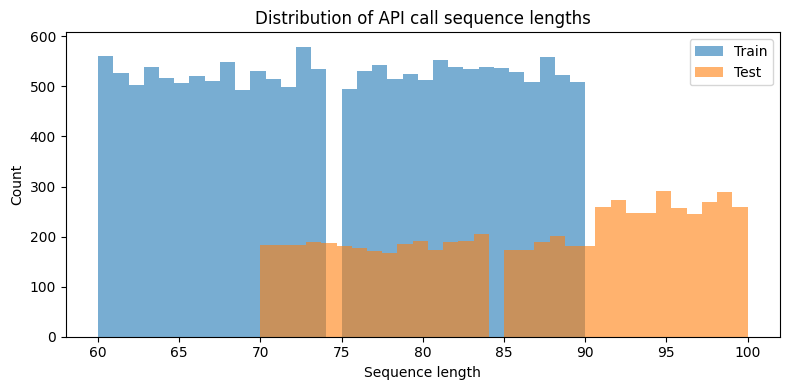

In [5]:
print(turn_red("Q) Compute the distribution of sequence lengths across both splits."))
print(turn_red("   Report min, max, mean, and median. Also, on the same figure, plot the training and testing length distributions using histograms."))
print(turn_red("   Compared to Lab 03 (CharacterTrajectories: 60–182 steps), how variable are these lengths?"))

############################################# YOUR SOLUTION HERE
import matplotlib.pyplot as plt

train_lengths = [len(s["api_call_sequence"]) for s in train_data]
test_lengths  = [len(s["api_call_sequence"]) for s in test_data]

for name, lengths in [("Train", train_lengths), ("Test", test_lengths)]:
    print(f"{name} — min: {min(lengths)}, max: {max(lengths)}, "
          f"mean: {np.mean(lengths):.1f}, median: {np.median(lengths):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_lengths, bins=32, alpha=0.6, label="Train")
ax.hist(test_lengths,  bins=32, alpha=0.6, label="Test")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Count")
ax.set_title("Distribution of API call sequence lengths")
ax.legend()
plt.tight_layout()
plt.show()

# Compared to Lab 03 (CharacterTrajectories: 60–182 steps), these sequences are much shorter and less variable:
# train lengths span ~60–90 and test ~70–100.
# The distribution is also more uniform within that narrow range,
# whereas CharacterTrajectories had a wider, more spread-out distribution.

In [6]:
print(turn_red("Q) Compute the class distribution in both splits. How imbalanced is the dataset?"))
print(turn_red("   What does this imply for:"))  
print(turn_red("      (a) your choice of loss function? Do you think that it is safe to use an unweighted one?"))
print(turn_red("      (b) which evaluation metric to trust? Is `accuracy` a reliable indicator?"))

############################################# YOUR SOLUTION HERE
from collections import Counter

for name, data in [("Train", train_data), ("Test", test_data)]:
    counts = Counter(s["is_malware"] for s in data)
    total = len(data)
    print(f"{name} — benign: {counts[0]} ({100*counts[0]/total:.1f}%), "
          f"malware: {counts[1]} ({100*counts[1]/total:.1f}%)")

# The dataset is heavily imbalanced: ~96% malware, ~4% benign.
#
# (a) An unweighted loss is not safe: the model would be biased toward predicting
#     malware for everything, largely ignoring the rare benign class.
#     A weighted CrossEntropyLoss (or class_weight='balanced') is needed.
#
# (b) Accuracy is misleading: a trivial model predicting "malware" for every sample
#     would already score ~96%. F1-score (especially for the benign class) or
#     ROC-AUC are much more informative metrics.

Q) Compute the class distribution in both splits. How imbalanced is the dataset?
   What does this imply for:
      (a) your choice of loss function? Do you think that it is safe to use an unweighted one?
      (b) which evaluation metric to trust? Is `accuracy` a reliable indicator?
Train — benign: 611 (3.7%), malware: 15714 (96.3%)
Test — benign: 243 (3.7%), malware: 6262 (96.3%)


In [7]:
print(turn_red("Q) How many unique API calls appear in the training set? In the test set?"))
print(turn_red("   Are there calls in the test set that never appeared in training (OOV)?"))
print(turn_red("   Why does this matter, and how will you handle it?"))

############################################# YOUR SOLUTION HERE
train_vocab = set(call for s in train_data for call in s["api_call_sequence"])
test_vocab  = set(call for s in test_data  for call in s["api_call_sequence"])
oov = test_vocab - train_vocab

print(f"Unique calls in train : {len(train_vocab)}")
print(f"Unique calls in test  : {len(test_vocab)}")
print(f"OOV calls in test     : {len(oov)} — {oov}")

# OOV calls matter because models built on the training vocabulary have no
# representation for unseen tokens.
# - BoW: OOV calls are accumulated in a dedicated UNK column, so the matrix
#   shape stays consistent.
# - Embedding-based models: OOV tokens are mapped to the <UNK> index, which
#   has its own learned (or zero-initialised) embedding.

Q) How many unique API calls appear in the training set? In the test set?
   Are there calls in the test set that never appeared in training (OOV)?
   Why does this matter, and how will you handle it?
Unique calls in train : 258
Unique calls in test  : 232
OOV calls in test     : 3 — {'WSASocketA', 'ControlService', 'NtDeleteKey'}


Q) Which API calls are most characteristic of malware? Of benign samples? Are the top-10 calls the same?
   Plot the top-10 most 'malware-biased' and 'benign-biased' calls.
   Remember: normalize counters with respect to the number of benign and malware calls.
   Notice: to compute the number of times a malware/benign call is made:
       - Initialize two dictionaries - one counting the frequency of malware calls, the other of benign calls
       - Iterate over benign and malware sequences
       - For each sequence, consider all calls in the sequence
       - Update the call counter
   Eventually, normalize the number of calls according to the number of benign and malign calls.
   Sort the dictionaries to retrieve the the top-10 calls. Use `sorted(your_dict.items(), key: lambda x:x[1], reverse=True)` to do so.


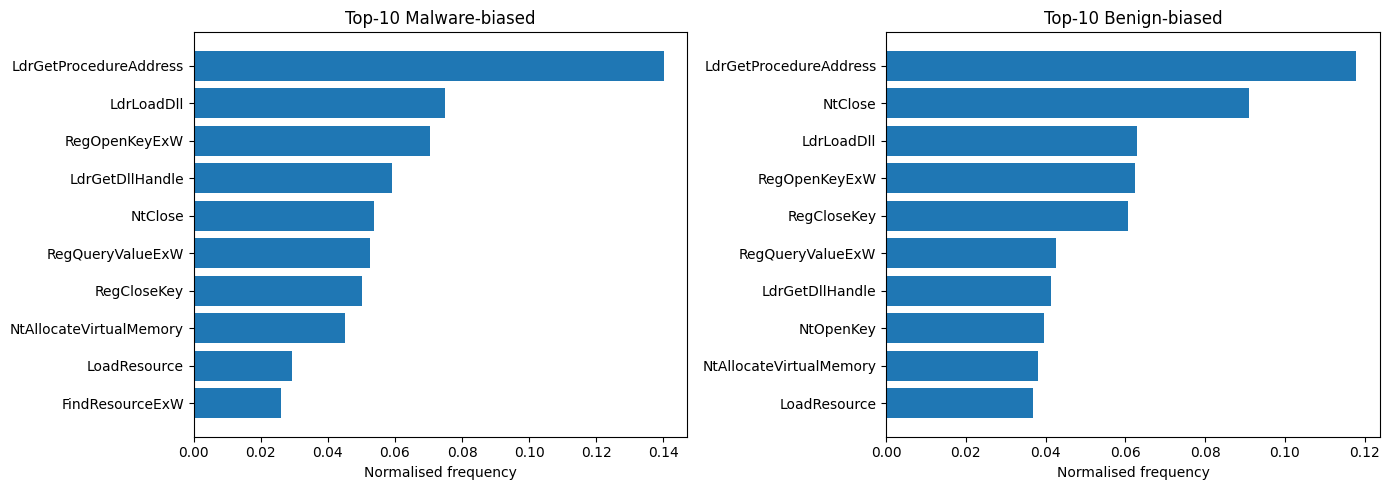

Calls in both top-10s (9/10): {'NtClose', 'RegOpenKeyExW', 'RegQueryValueExW', 'LdrLoadDll', 'LdrGetDllHandle', 'LoadResource', 'LdrGetProcedureAddress', 'RegCloseKey', 'NtAllocateVirtualMemory'}


In [8]:
print(turn_red("Q) Which API calls are most characteristic of malware? Of benign samples? Are the top-10 calls the same?"))
print(turn_red("   Plot the top-10 most 'malware-biased' and 'benign-biased' calls."))
print(turn_red("   Remember: normalize counters with respect to the number of benign and malware calls."))
print(turn_red("   Notice: to compute the number of times a malware/benign call is made:"))
print(turn_red("       - Initialize two dictionaries - one counting the frequency of malware calls, the other of benign calls"))
print(turn_red("       - Iterate over benign and malware sequences"))
print(turn_red("       - For each sequence, consider all calls in the sequence"))
print(turn_red("       - Update the call counter"))
print(turn_red("   Eventually, normalize the number of calls according to the number of benign and malign calls."))
print(turn_red("   Sort the dictionaries to retrieve the the top-10 calls. Use `sorted(your_dict.items(), key: lambda x:x[1], reverse=True)` to do so."))

############################################# YOUR SOLUTION HERE
malware_counts = {}
benign_counts  = {}

for s in train_data:
    target = malware_counts if s["is_malware"] == 1 else benign_counts
    for call in s["api_call_sequence"]:
        target[call] = target.get(call, 0) + 1

total_malware = sum(malware_counts.values())
total_benign  = sum(benign_counts.values())

malware_norm = {k: v / total_malware for k, v in malware_counts.items()}
benign_norm  = {k: v / total_benign  for k, v in benign_counts.items()}

top10_malware = sorted(malware_norm.items(), key=lambda x: x[1], reverse=True)[:10]
top10_benign  = sorted(benign_norm.items(),  key=lambda x: x[1], reverse=True)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top10, title in zip(axes, [top10_malware, top10_benign], ["Top-10 Malware-biased", "Top-10 Benign-biased"]):
    calls, freqs = zip(*top10)
    ax.barh(calls[::-1], freqs[::-1])
    ax.set_xlabel("Normalised frequency")
    ax.set_title(title)
plt.tight_layout()
plt.show()

malware_top_calls = {c for c, _ in top10_malware}
benign_top_calls  = {c for c, _ in top10_benign}
overlap = malware_top_calls & benign_top_calls
print(f"Calls in both top-10s ({len(overlap)}/10): {overlap}")

# The top-10 lists are almost identical (9/10 overlap). The distinction lies in
# relative frequencies, not in which calls appear.

---
## Block 02 — Bag-of-Words Baseline

The simplest way to represent a sequence of words is by using the so-called **Bag of Words (BoW)** approach.

In BoW approaches, each sequence is a row and the vocabulary (i.e., all words that can be used in the sequences) columns.

To build a BoW matrix, we count how many times each word appears in the sequence. We put 0 if the word never appears in that sequence. 

Observe the following schema, in which we provide an example given two sequences of calls:

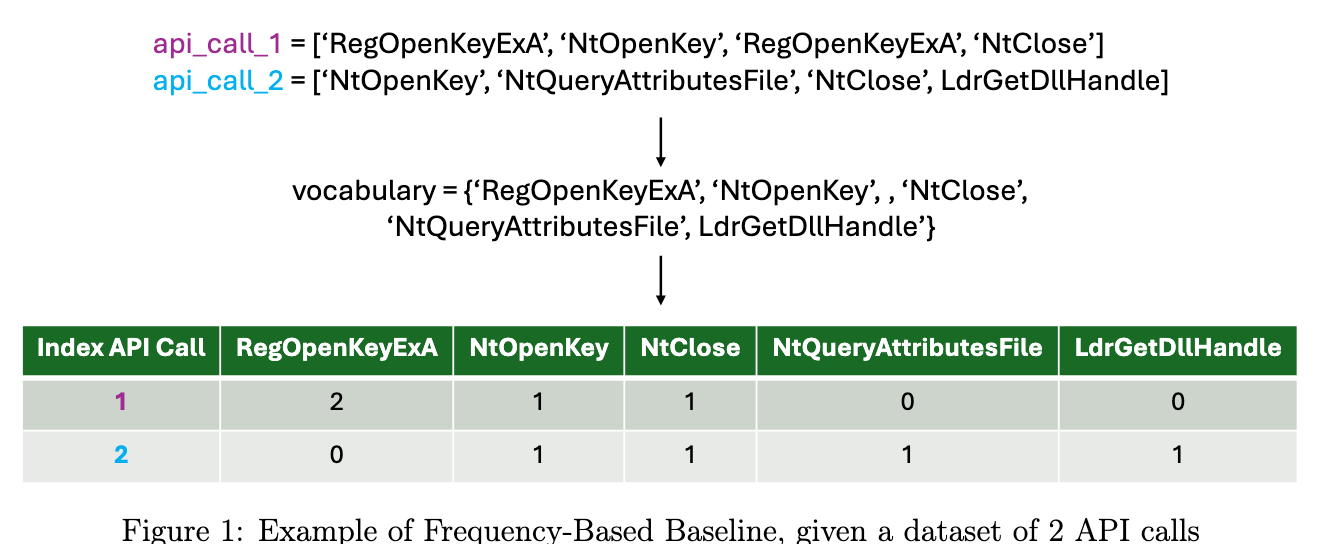

In [9]:
display_image("schema/BoW.png", width=600, height=300)

**In practise**: each sample becomes a histogram over the vocabulary — a fixed-size vector that any classic ML model can consume.

This directly connects to **Lab 01**: you will use a **Random Forest** classifier, tuned with cross-validated grid search.

In [10]:
print(turn_red("Q) With this approach, are we keeping the original order of the calls?"))

############################################# YOUR SOLUTION HERE
# No. BoW only counts how many times each API call appears in the sequence;
# the position information is completely discarded.
# Two sequences with the same calls in different orders produce identical BoW vectors.


Q) With this approach, are we keeping the original order of the calls?


In [11]:
print(turn_red("In the following, we provide a function to implement build the BoW matrix starting from some input sequences."))
print(turn_red("Notice: The method requires a vocabulary - all the api calls in the dataset, that you will use as columns to construct the matrix."))
print(turn_red("Q) Which partition do you use to extract the vocabulary? Can you use the test set?"))

############################################# DO NOT CHANGE
def build_bow_features(sequences, vocab):
    """
    Build a Bag-of-Words count matrix.
      - sequences : list of lists of strings
      - vocab     : set/list of known tokens (built from the TRAINING set)
    Returns a float32 numpy array of shape (n_samples, |vocab| + 1).
    The last column accumulates counts for unknown tokens (UNK).
    """
    vocab_to_idx = {w: i for i, w in enumerate(sorted(vocab))}
    X = np.zeros((len(sequences), len(vocab) + 1), dtype=np.float32)
    for i, seq in enumerate(sequences):
        for call in seq:
            idx = vocab_to_idx.get(call, len(vocab))   # unknown → UNK column
            X[i, idx] += 1
    return X

############################################# YOUR SOLUTION HERE
# We must use only the TRAINING set to build the vocabulary.
# Using the test set would constitute data leakage: in a real deployment
# the model has no access to future/unseen data when building its feature space.
train_vocab = set(call for s in train_data for call in s["api_call_sequence"])
print(f"Vocabulary size (training): {len(train_vocab)} unique API calls")


In the following, we provide a function to implement build the BoW matrix starting from some input sequences.
Notice: The method requires a vocabulary - all the api calls in the dataset, that you will use as columns to construct the matrix.
Q) Which partition do you use to extract the vocabulary? Can you use the test set?
Vocabulary size (training): 258 unique API calls


In [12]:
print(turn_red("Q) Use build_bow_features() to build BoW matrices for train and test."))
print(turn_red("   What shape do the resulting matrices have? Is it consistent with previous results?"))
print(turn_red("   How sparse are they on average (fraction of non-zero columns per row)?"))

############################################# YOUR SOLUTION HERE
train_seqs = [s["api_call_sequence"] for s in train_data]
test_seqs  = [s["api_call_sequence"] for s in test_data]
y_train    = np.array([s["is_malware"] for s in train_data])
y_test     = np.array([s["is_malware"] for s in test_data])

X_train_bow = build_bow_features(train_seqs, train_vocab)
X_test_bow  = build_bow_features(test_seqs,  train_vocab)

print(f"Train BoW shape : {X_train_bow.shape}")
print(f"Test  BoW shape : {X_test_bow.shape}")

# Sparsity: fraction of non-zero columns per row
train_sparsity = (X_train_bow != 0).mean(axis=1).mean()
test_sparsity  = (X_test_bow  != 0).mean(axis=1).mean()
print(f"Avg fraction of non-zero columns — train: {train_sparsity:.3f}, test: {test_sparsity:.3f}")
# Shape is (n_samples, |vocab|+1) = (n_samples, 259), consistent with 258 unique training calls + 1 UNK column.
# Matrices are very sparse: most sequences use only a small subset of the full vocabulary.


Q) Use build_bow_features() to build BoW matrices for train and test.
   What shape do the resulting matrices have? Is it consistent with previous results?
   How sparse are they on average (fraction of non-zero columns per row)?
Train BoW shape : (16325, 259)
Test  BoW shape : (6505, 259)
Avg fraction of non-zero columns — train: 0.085, test: 0.094


In [13]:
print(turn_red("Q) Train a Shallow Learning Classifier with cross-validated hyperparameter search (recall Lab 01)."))
print(turn_red("   Use class_weight='balanced'. Optimise for F1."))
print(turn_red("   Why is accuracy a poor scoring metric here?"))

############################################# YOUR SOLUTION HERE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf_param_grid = {
    "n_estimators"     : [200, 500],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf" : [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train_bow, y_train)
print(f"Best CV F1-macro: {rf_grid.best_score_:.4f}")
print(f"Best params     : {rf_grid.best_params_}")

# Accuracy is a poor metric here because the dataset is heavily imbalanced (~96% malware).
# A model that always predicts malware achieves ~96% accuracy while completely failing
# on the minority (benign) class. F1-macro treats both classes equally.


Q) Train a Shallow Learning Classifier with cross-validated hyperparameter search (recall Lab 01).
   Use class_weight='balanced'. Optimise for F1.
   Why is accuracy a poor scoring metric here?
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV F1-macro: 0.7996
Best params     : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}


Q) Evaluate the best RF on the test set.
   Report the full classification report and the confusion matrix.
              precision    recall  f1-score   support

      benign       0.69      0.58      0.63       243
     malware       0.98      0.99      0.99      6262

    accuracy                           0.97      6505
   macro avg       0.84      0.78      0.81      6505
weighted avg       0.97      0.97      0.97      6505



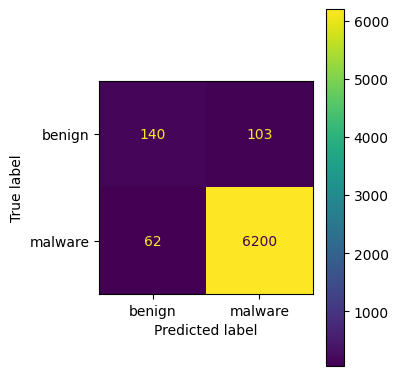

In [14]:
print(turn_red("Q) Evaluate the best RF on the test set."))
print(turn_red("   Report the full classification report and the confusion matrix."))

############################################# YOUR SOLUTION HERE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_bow)

print(classification_report(y_test, y_pred_rf, target_names=["benign", "malware"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=["benign", "malware"], ax=ax)
plt.tight_layout()
plt.show()

# Malware: F1=0.99 — nearly perfect (easy, it's the majority class)
# Benign: F1=0.49 — recall only 0.35, meaning ~65% of benign samples get misclassified as malware
# Macro F1=0.74 exposes the real weakness; accuracy (0.97) is misleading

---
## Block 03 — FFNN with Learned Embeddings

BoW approaches represent simple baselines that gives away some info of the original data (e.g., the order).

Following the example of Lab 2, we can do something more sophisticated than that. 

For instance, rather than representing each API call with a raw count, we can learn a **dense embedding** — a compact vector that the network adjusts during training so that semantically similar calls end up close together in embedding space.

We will try this approach initially relying on FFNN.

In [15]:
print(turn_red("Q) Do you think that FFNN are the most suitable choice here? Why?"))
# Fixed-size input constraint forces artificial padding/truncation
# Mean-pooling after embedding collapses order → same as BoW for sequence structure
# Still better than BoW (learned embeddings vs raw counts), but LSTM is the right tool

print(turn_red("Q) How do you think you will have to deal with the problem? How did we tackle this scenario in Lab 03?"))
# 3 steps: 
# Tokenise — build_vocab + encode_sequences (train set only)
# Fix the length — pad/truncate to FIXED_LEN = median(train_lengths)
# Embed + pool — learned embeddings mean-pooled with a padding mask
# FFNN path (Lab 03): pad_or_truncate with FIXED_LEN = median, padding mask during mean-pooling
# LSTM path (Lab 03): SeqDataset + per-batch collate_fn + pack_padded_sequence to fully ignore padding

Q) Do you think that FFNN are the most suitable choice here? Why?
Q) How do you think you will have to deal with the problem? How did we tackle this scenario in Lab 03?


In [16]:
print(turn_red("In the following, we provide two fuctions (`build_vocab` and `encode_sequences`)."))
print(turn_red("Use these function to encode the input string sequences into numerical identifiers that the FFNN can process."))
print(turn_red("Q) We are introducing 2 extra words, <PAD> and <UNK>. Why do you think it is the case?"))
print(turn_red("Q) Which partition do you use to build the vocabulary?"))
print(turn_red("Q) How many words are there in the vocabulary? Is it consistent with previous results?"))
print(turn_red("Q) Print the first training sequence BEFORE and AFTER encoding."))

############################################# DO NOT CHANGE

def build_vocab(sequences):
    """Map each unique token to an integer. Index 0: <PAD>, 1: <UNK>."""
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for seq in sequences:
        for token in seq:
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

def encode_sequences(sequences, vocab):
    """Replace each token with its vocab index; unknowns → <UNK> index."""
    unk = vocab['<UNK>']
    return [[vocab.get(tok, unk) for tok in seq] for seq in sequences]

############################################# YOUR SOLUTION HERE
# <PAD> (index 0) is needed to bring all sequences to the same fixed length:
# shorter sequences are filled with zeros up to FIXED_LEN.
# <UNK> (index 1) handles OOV tokens that appear in test but not in training.
# Both are reserved slots that must not collide with real API call indices.

# Vocabulary is built from the TRAINING set only (no leakage from test).
vocab = build_vocab(train_seqs)
print(f"Vocabulary size (incl. <PAD> and <UNK>): {len(vocab)}")
# Expected: 258 unique calls + 2 special tokens = 260 — consistent with Block 01.

train_indexed = encode_sequences(train_seqs, vocab)
test_indexed  = encode_sequences(test_seqs,  vocab)

print("\nFirst training sequence BEFORE encoding:")
print(train_seqs[0][:10], "...")
print("\nFirst training sequence AFTER encoding:")
print(train_indexed[0][:10], "...")

In the following, we provide two fuctions (`build_vocab` and `encode_sequences`).
Use these function to encode the input string sequences into numerical identifiers that the FFNN can process.
Q) We are introducing 2 extra words, <PAD> and <UNK>. Why do you think it is the case?
Q) Which partition do you use to build the vocabulary?
Q) How many words are there in the vocabulary? Is it consistent with previous results?
Q) Print the first training sequence BEFORE and AFTER encoding.
Vocabulary size (incl. <PAD> and <UNK>): 260

First training sequence BEFORE encoding:
['LdrGetDllHandle', 'LdrGetProcedureAddress', 'LdrLoadDll', 'LdrGetProcedureAddress', 'LdrGetDllHandle', 'LdrGetProcedureAddress', 'GetTimeZoneInformation', 'LoadStringW', 'RegOpenKeyExW', 'RegQueryValueExW'] ...

First training sequence AFTER encoding:
[2, 3, 4, 3, 2, 3, 5, 6, 7, 8] ...


In [17]:
print(turn_red("Q) Now, build a function that i) pads or truncates sequences and ii) turns them into numpy arrays. Choose a suitable `FIXED_LEN` parameter."))
print(turn_red("Q) What is the final shape of the training dataset? What is the one of the testing dataset?"))

############################################# YOUR SOLUTION HERE
FIXED_LEN = int(np.median([len(seq) for seq in train_indexed]))  # = 75

def pad_or_truncate(sequences, fixed_len):
    result = np.zeros((len(sequences), fixed_len), dtype=np.int64)
    for i, seq in enumerate(sequences):
        length = min(len(seq), fixed_len)
        result[i, :length] = seq[:length]
    return result

X_train = pad_or_truncate(train_indexed, FIXED_LEN)
X_test  = pad_or_truncate(test_indexed,  FIXED_LEN)

print(f"FIXED_LEN       : {FIXED_LEN}")
print(f"X_train shape   : {X_train.shape}")
print(f"X_test  shape   : {X_test.shape}")

# FIXED_LEN = 75 (the median) is a good choice: 
# it's also the mean and the max here (sequences range 60–90), 
# so truncation is minimal and padding is moderate.

Q) Now, build a function that i) pads or truncates sequences and ii) turns them into numpy arrays. Choose a suitable `FIXED_LEN` parameter.
Q) What is the final shape of the training dataset? What is the one of the testing dataset?
FIXED_LEN       : 75
X_train shape   : (16325, 75)
X_test  shape   : (6505, 75)


In [18]:
from sklearn.model_selection import train_test_split
print(turn_red("Q) Split the training data into 80/20. Do you need to use stratified sampling?"))

############################################# YOUR SOLUTION HERE
# Stratified sampling is needed because the dataset is heavily imbalanced (~96% malware).
# Without it, the validation split might accidentally contain very few or no benign samples.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f"Train : {X_tr.shape}, Val : {X_val.shape}")


Q) Split the training data into 80/20. Do you need to use stratified sampling?
Train : (13060, 75), Val : (3265, 75)


In [19]:
print(turn_red("In the following, we provide the code to compute the class weights for each class. They will be useful later to compute the losses."))
print(turn_red("Q) What is the weight for the benign class (cw[0])? What is the weigth of the malign one (cw[1])?"))

############################################# DO NOT CHANGE

from sklearn.utils import compute_class_weight
classes_ = np.unique(y_tr)
cw = compute_class_weight('balanced', classes=classes_, y=y_tr)

############################################# YOUR SOLUTION HERE
print(f"Weight benign  (cw[0]): {cw[0]:.4f}")
print(f"Weight malware (cw[1]): {cw[1]:.4f}")

# cw[0] (benign)  ≈ 13.35 — much higher weight because benign is the rare class (~4%).
# cw[1] (malware) ≈ 0.52  — lower weight because malware dominates (~96%).
# These weights are passed to CrossEntropyLoss so each benign misclassification
# incurs ~26x more penalty than a malware misclassification, compensating for imbalance.


In the following, we provide the code to compute the class weights for each class. They will be useful later to compute the losses.
Q) What is the weight for the benign class (cw[0])? What is the weigth of the malign one (cw[1])?
Weight benign  (cw[0]): 13.3538
Weight malware (cw[1]): 0.5194


In [20]:
import torch
print(turn_red("Eventually, create train, validation and test dataloaders. We provide a simple function to create the datasets."))

############################################# DO NOT CHANGE

from torch.utils.data import TensorDataset, DataLoader
def create_ds(X, y):
    return TensorDataset(torch.tensor(X, dtype=torch.long),
                         torch.tensor(y, dtype=torch.long))

############################################# YOUR SOLUTION HERE
BATCH_SIZE = 64

train_ds = create_ds(X_tr,    y_tr)
val_ds   = create_ds(X_val,   y_val)
test_ds  = create_ds(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Eventually, create train, validation and test dataloaders. We provide a simple function to create the datasets.
Train batches: 205 | Val: 52 | Test: 102


In [21]:
print(turn_red("Now, focus on the FFNN model. This time, you are dealing with sequences of categorical features which you will have to embed (mix of Lab 2 and Lab 3)."))
print(turn_red("   - The model receives a batch B of sequences."))
print(turn_red("   - Each sequence have T API calls (you set T to `Fixed Len` earlier on)."))
print(turn_red("   - You encoded each call into a numerical identifier (`encode_sequences`)."))
print(turn_red("   - Final shape of the input data: BxTx1"))
print(turn_red("This FFNN model must:"))
print(turn_red("   - Use an embedding layer to map the identifiers into embeddings (BxTx1 > BxTxh)"))
print(turn_red("   - Similarly to Lab 2, map the 3D input matrix (BxTxh) into a 2D input matrix (Bx(Txh))"))
print(turn_red("   - While in Lab 2 we flatten the matrix, here we will aggregate the last dimension with a mean aggregator"))
print(turn_red("      In other terms, we will compute the mean over the last dimension."))
print()
print(turn_red("We provide the code to instantiate the model. Answer to the following questions:"))
print(turn_red("   - Q) How many layers does the MLP layer have?"))
print(turn_red("   - Q) Which is the line converting the numerical identifiers into embeddings?"))
print(turn_red("   - Q) Why are we using a padding mask?"))
print(turn_red("   - Q) Can we still track the orderd of the calls after the aggregation?"))


############################################# DO NOT CHANGE
from torch import nn
class EmbedderMLP(nn.Module):
    """
    MLP classifier with an embedding front-end
    Forward pass:
      1. Look up each integer token in the embedding table.
            (batch, seq_len)  →  (batch, seq_len, embedding_dim)
      2. Mean-pool the embeddings, masking out <PAD> positions 
            (batch, seq_len, embedding_dim)  →  (batch, embedding_dim)
      3. MLP head → class logits.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 num_classes, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.fc1     = nn.Linear(embedding_dim, hidden_dim)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb  = self.embedding(x)                                  # (B, T, D)
        mask = (x != self.embedding.padding_idx).unsqueeze(-1)    # (B, T, 1)
        # Masked mean: sum over real tokens, divide by number of real tokens
        pooled = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)   # (B, D)
        return self.fc2(self.dropout(self.relu(self.fc1(pooled))))
  
############################################# YOUR SOLUTION HERE

# Q) How many layers does the MLP have?
# 2 layers: fc1 (embedding_dim → hidden_dim) and fc2 (hidden_dim → num_classes),
# with ReLU activation and Dropout in between.

# Q) Which line converts numerical identifiers into embeddings?
# emb = self.embedding(x)   →  (B, T, embedding_dim)
# nn.Embedding acts as a lookup table: each integer index retrieves its dense vector.

# Q) Why are we using a padding mask?
# Sequences were padded with index 0 (<PAD>) to reach FIXED_LEN. Those positions
# carry no real information. The mask (x != padding_idx) excludes them from the
# mean-pooling so that padding zeros don't dilute the actual call embeddings.

# Q) Can we still track the order of calls after aggregation?
# No. Mean-pooling collapses the T timesteps into a single vector by averaging
# across the sequence dimension. All positional information is lost — two sequences
# with the same calls in different orders produce the same pooled representation.

Now, focus on the FFNN model. This time, you are dealing with sequences of categorical features which you will have to embed (mix of Lab 2 and Lab 3).
   - The model receives a batch B of sequences.
   - Each sequence have T API calls (you set T to `Fixed Len` earlier on).
   - You encoded each call into a numerical identifier (`encode_sequences`).
   - Final shape of the input data: BxTx1
This FFNN model must:
   - Use an embedding layer to map the identifiers into embeddings (BxTx1 > BxTxh)
   - Similarly to Lab 2, map the 3D input matrix (BxTxh) into a 2D input matrix (Bx(Txh))
   - While in Lab 2 we flatten the matrix, here we will aggregate the last dimension with a mean aggregator
      In other terms, we will compute the mean over the last dimension.

We provide the code to instantiate the model. Answer to the following questions:
   - Q) How many layers does the MLP layer have?
   - Q) Which is the line converting the numerical identifiers into embeddings?
   - Q) Why are we us

In [22]:
print(turn_red("We provide some of the functions to train your models (both the FFNN and the LSTM later)."))
print(turn_red("   Q) The `run_training` function is slightly different from usual. Which is the model we are saving at the end of the loop?"))


def run_training(model, train_loader, val_loader, optimizer, criterion,
                 epochs, device, model_type='mlp', print_every=5):
    """Train with early stopping on validation loss (keeps best model)."""
    best_val_loss, best_state = float('inf'), None
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(epochs):
        tl = train_epoch(model, train_loader, optimizer, criterion, device, model_type)
        vl = eval_epoch(model, val_loader, criterion, device, model_type)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}]  Train: {tl:.4f}  Val: {vl:.4f}")
    model.load_state_dict(best_state)
    return model, history

def _forward(model, batch, device, model_type):
    """Single forward pass. Handles both MLP (2-tuple batch) and LSTM (3-tuple)."""
    if model_type == 'lstm':
        seqs, lengths, labels = batch
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs, lengths)
    else:
        seqs, labels = batch
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
    return logits, labels

def get_predictions(model, loader, device, model_type='mlp'):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            logits, labels = _forward(model, batch, device, model_type)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    return np.array(preds_all), np.array(labels_all)

def train_epoch(model, loader, optimizer, criterion, device, model_type='mlp'):
    model.train()
    total_loss = 0.0
    for batch in loader:
        optimizer.zero_grad()
        logits, labels = _forward(model, batch, device, model_type)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device, model_type='mlp'):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            logits, labels = _forward(model, batch, device, model_type)
            total_loss += criterion(logits, labels).item()
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    return avg_loss

# It saves the model with the LOWEST VALIDATION LOSS seen across all epochs
# (early stopping / best-model checkpoint), not the model from the last epoch.
# This is done via:
#   best_state = {k: v.clone() for k, v in model.state_dict().items()}
# stored whenever vl < best_val_loss, and then restored at the end with:
#   model.load_state_dict(best_state)
# This prevents overfitting: the final model is the one that generalised best
# on the validation set, even if later epochs overfit.

We provide some of the functions to train your models (both the FFNN and the LSTM later).
   Q) The `run_training` function is slightly different from usual. Which is the model we are saving at the end of the loop?


Q) Instantiate and train an EmbedderMLP. Choose hyperparameters (hidden_dim, lr, epochs, etc.) and the optimizer.
Q) Consider the number of API calls in your dataset. Which is a good value for the embedding_dim to not compress too much the information?
   Notice: we already provided the code for the weighted CrossEntropyLoss.
Q) Plot the training and validation lossess. use the `history` output of `run_training`.
Epoch [  1/150]  Train: 0.7342  Val: 0.7279
Epoch [  5/150]  Train: 0.6894  Val: 0.6779
Epoch [ 10/150]  Train: 0.6449  Val: 0.6203
Epoch [ 15/150]  Train: 0.5960  Val: 0.5702
Epoch [ 20/150]  Train: 0.5687  Val: 0.5353
Epoch [ 25/150]  Train: 0.5415  Val: 0.5095
Epoch [ 30/150]  Train: 0.5268  Val: 0.4895
Epoch [ 35/150]  Train: 0.5075  Val: 0.4740
Epoch [ 40/150]  Train: 0.5000  Val: 0.4624
Epoch [ 45/150]  Train: 0.4747  Val: 0.4512
Epoch [ 50/150]  Train: 0.4650  Val: 0.4416
Epoch [ 55/150]  Train: 0.4641  Val: 0.4345
Epoch [ 60/150]  Train: 0.4568  Val: 0.4266
Epoch [ 65/

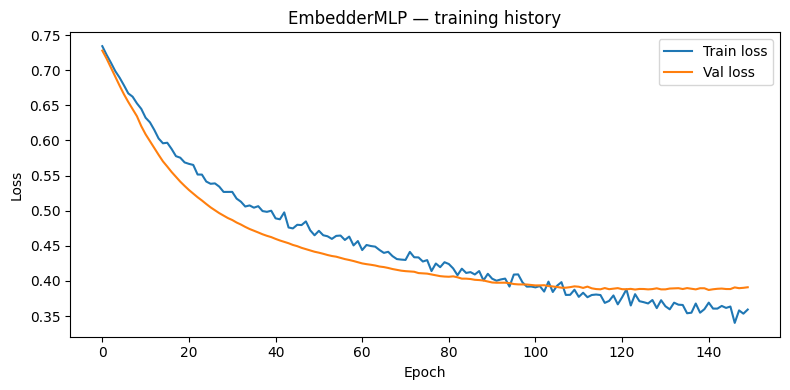

In [23]:
print(turn_red("Q) Instantiate and train an EmbedderMLP. Choose hyperparameters (hidden_dim, lr, epochs, etc.) and the optimizer."))
print(turn_red("Q) Consider the number of API calls in your dataset. Which is a good value for the embedding_dim to not compress too much the information?"))
print(turn_red("   Notice: we already provided the code for the weighted CrossEntropyLoss."))
print(turn_red("Q) Plot the training and validation lossess. use the `history` output of `run_training`."))

############################################# DO NOT CHANGE
import random
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(RANDOM_STATE)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Use weights we previously obtained
class_weights_emb = torch.tensor(cw, dtype=torch.float32).to(device)
# Create a weighted crossentropy loss
criterion_emb = nn.CrossEntropyLoss(weight=class_weights_emb)

############################################# YOUR SOLUTION HERE
# embedding_dim: with 258 unique API calls, 64 dimensions preserves enough
# information without over-compressing (rule of thumb: mean between sqrt(vocab_size) = 64 and vocab_size/4=16).

VOCAB_SIZE    = len(vocab)   # 260
EMBEDDING_DIM = 32
HIDDEN_DIM    = 8
NUM_CLASSES   = 2
LR            = 1e-4
EPOCHS        = 150

mlp_model = EmbedderMLP(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    num_classes   = NUM_CLASSES,
).to(device)

optimizer_emb = torch.optim.Adam(mlp_model.parameters(), lr=LR)

mlp_model, history_emb = run_training(
    mlp_model, train_loader, val_loader,
    optimizer_emb, criterion_emb,
    epochs=EPOCHS, device=device, model_type='mlp', print_every=5
)

# Plot losses
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_emb['train_loss'], label='Train loss')
ax.plot(history_emb['val_loss'],   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('EmbedderMLP — training history')
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
print(turn_red("Evaluate the EmbedderMLP on the test set."))
print(turn_red("   Q) How does it compare to the BoW baseline? Why do you think it is the case?"))

############################################# YOUR SOLUTION HERE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd

y_pred_mlp, y_true_mlp = get_predictions(mlp_model, test_loader, device, model_type='mlp')

# Build comparison table automatically
def get_f1_summary(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred,
                                   target_names=["benign", "malware"],
                                   output_dict=True)
    return {
        "Model"       : model_name,
        "Benign F1"   : round(report["benign"]["f1-score"],   2),
        "Malware F1"  : round(report["malware"]["f1-score"],  2),
        "Macro F1"    : round(report["macro avg"]["f1-score"], 2),
        "Accuracy"    : round(report["accuracy"],              2),
    }

rows = [
    get_f1_summary(y_test,    y_pred_rf,  "BoW + RF"),
    get_f1_summary(y_true_mlp, y_pred_mlp, "EmbedderMLP"),
]
print(pd.DataFrame(rows).to_string(index=False))

print("\n=== EmbedderMLP — full report ===")
print(classification_report(y_true_mlp, y_pred_mlp, target_names=["benign", "malware"]))

# Automated commentary
bow_f1  = rows[0]["Macro F1"]
mlp_f1  = rows[1]["Macro F1"]
diff    = round(bow_f1 - mlp_f1, 2)
winner  = "BoW + RF" if bow_f1 > mlp_f1 else "EmbedderMLP"

print(f"► {winner} achieves higher macro F1 (gap: {abs(diff):.2f}).")
if bow_f1 > mlp_f1:
    print("  Both models discard call order, so the FFNN gains no structural advantage.")
    print("  With only 258 unique API calls, raw counts are already highly discriminative.")
    print("  RF also handles class imbalance more robustly than a weighted cross-entropy loss.")
else:
    print("  Learned embeddings capture richer token similarity than raw counts.")
    print("  The FFNN benefits from end-to-end training with the weighted loss.")


Evaluate the EmbedderMLP on the test set.
   Q) How does it compare to the BoW baseline? Why do you think it is the case?
      Model  Benign F1  Malware F1  Macro F1  Accuracy
   BoW + RF       0.63        0.99      0.81      0.97
EmbedderMLP       0.28        0.92      0.60      0.85

=== EmbedderMLP — full report ===
              precision    recall  f1-score   support

      benign       0.17      0.78      0.28       243
     malware       0.99      0.86      0.92      6262

    accuracy                           0.85      6505
   macro avg       0.58      0.82      0.60      6505
weighted avg       0.96      0.85      0.89      6505

► BoW + RF achieves higher macro F1 (gap: 0.21).
  Both models discard call order, so the FFNN gains no structural advantage.
  With only 258 unique API calls, raw counts are already highly discriminative.
  RF also handles class imbalance more robustly than a weighted cross-entropy loss.


---
## Block 04 — LSTM Classifier on Categorical Sequences

Both BoW and the EmbedderMLP ignore the **order** of API calls. 

Contrarily, an LSTM can, in principle, capture temporal patterns 
   e.g., *"LdrLoadDll followed immediately by NtWriteVirtualMemory is more suspicious than either call alone"*.

In the following, you will combine what you learned in Lab 02 and Lab 03. Specifically, you will use:

- **Embedding layer** (Lab 02) → encode each categorical token as a dense vector.
- **LSTM** (Lab 03) → process the sequence of embedded vectors step by step.

The key insight is that the LSTM's `input_size` is no longer the number of raw input features - it is the **embedding dimension**: 
each timestep feeds the embedding vector for that API call into the LSTM cell.

```
integer indices  ──►  [Embedding]  ──►  dense vector per timestep
                                                    │
                                                    ▼
                                               [LSTM]  ──►  hidden state (last step)
                                                                        │
                                                                        ▼
                                                               [Linear]  ──►  logits
```

In [25]:
print(turn_red("Create a Pytorch dataset to process the input sequences."))
print(turn_red("   Remember that you already encoded the strings into numerical identifiers: hence, you can follow the example of Lab 3 here."))
############################################# YOUR SOLUTION HERE

from torch.utils.data import Dataset

class APICallDataset(Dataset):
    """Dataset that stores variable-length encoded sequences and their labels."""
    def __init__(self, sequences, labels):
        self.sequences = sequences   # list of list[int]
        self.labels    = labels      # array-like of int

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq   = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx],    dtype=torch.long)
        return seq, label


Create a Pytorch dataset to process the input sequences.
   Remember that you already encoded the strings into numerical identifiers: hence, you can follow the example of Lab 3 here.


### Dynamic padding with a custom collate function

Sequences in a batch may have different lengths. As in Lab 03, you need a
**collate function** that:
1. Pads the sequences in a batch to the length of the longest one in that batch.
2. Records the **original lengths** so the LSTM can skip padding tokens via
   `pack_padded_sequence`.

The collate function should return a 3-tuple: `(padded_sequences, lengths, labels)`.

In [26]:
print(turn_red("Q) Implement the collate function for the DataLoader (recall Lab 03)."))
print(turn_red("   It receives a list of (sequence_tensor, label) pairs and must return:"))
print(turn_red("     (padded_sequences, lengths, labels)"))
print(turn_red("   Pad to the longest sequence in the batch (padding_value=0)."))
print(turn_red("   Hint: as in Lab 03, you can use torch.nn.utils.rnn.pad_sequence."))

############################################# YOUR SOLUTION HERE

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pad a batch of variable-length sequences to the longest one in that batch."""
    sequences, labels = zip(*batch)
    lengths  = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    padded   = pad_sequence(sequences, batch_first=True, padding_value=0)   # (B, T_max)
    labels   = torch.stack(labels)
    return padded, lengths, labels


Q) Implement the collate function for the DataLoader (recall Lab 03).
   It receives a list of (sequence_tensor, label) pairs and must return:
     (padded_sequences, lengths, labels)
   Pad to the longest sequence in the batch (padding_value=0).
   Hint: as in Lab 03, you can use torch.nn.utils.rnn.pad_sequence.


In [27]:
print(turn_red("Q) Re-use the encoded sequences from Block 03 (train_indexed, test_indexed)."))
print(turn_red("   Create an 80/20 stratified train/val split."))
print(turn_red("   Build APICallDataset objects and DataLoaders with collate_fn."))
print(turn_red("   Compute class weights from the training split."))

############################################# YOUR SOLUTION HERE

from sklearn.model_selection import train_test_split as tts
from sklearn.utils import compute_class_weight

# 80/20 stratified split (same rationale as Block 03: heavy class imbalance)
tr_seqs, val_seqs, y_tr_l, y_val_l = tts(
    train_indexed, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Class weights from the training split
cw_lstm = compute_class_weight("balanced", classes=np.unique(y_tr_l), y=y_tr_l)
print(f"Class weights — benign: {cw_lstm[0]:.4f}, malware: {cw_lstm[1]:.4f}")

# Datasets
train_ds_lstm = APICallDataset(tr_seqs,      y_tr_l)
val_ds_lstm   = APICallDataset(val_seqs,     y_val_l)
test_ds_lstm  = APICallDataset(test_indexed, y_test)

# DataLoaders with the custom collate function
BATCH_LSTM = 64
train_loader_lstm = DataLoader(train_ds_lstm, batch_size=BATCH_LSTM, shuffle=True,  collate_fn=collate_fn)
val_loader_lstm   = DataLoader(val_ds_lstm,   batch_size=BATCH_LSTM, shuffle=False, collate_fn=collate_fn)
test_loader_lstm  = DataLoader(test_ds_lstm,  batch_size=BATCH_LSTM, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader_lstm)} | Val: {len(val_loader_lstm)} | Test: {len(test_loader_lstm)}")


Q) Re-use the encoded sequences from Block 03 (train_indexed, test_indexed).
   Create an 80/20 stratified train/val split.
   Build APICallDataset objects and DataLoaders with collate_fn.
   Compute class weights from the training split.
Class weights — benign: 13.3538, malware: 0.5194
Train batches: 205 | Val: 52 | Test: 102


In [28]:
print(turn_red("Use the provided `LSTMClassifier` to classify the sequences of calls."))
print(turn_red("Q) Is the embedding layer different with respect to the one of the FFNN?"))
print(turn_red("Q) Where do you iteratively process the embeddings?1"))

############################################# YOUR SOLUTION HERE

# Q) Is the embedding layer different from the FFNN's?
# No — both use nn.Embedding(vocab_size, embedding_dim, padding_idx=0).
# The difference is what happens AFTER embedding:
#   EmbedderMLP: masked mean-pool over time → fixed-size vector → MLP
#   LSTMClassifier: feed each embedding step-by-step into the LSTM → last hidden state → Linear

# Q) Where do you iteratively process the embeddings?
# Inside the LSTM cell: at each time step t, the LSTM reads the embedding of token t
# and updates its hidden state h_t given h_{t-1} and the current input.
# pack_padded_sequence ensures the LSTM skips padding positions.

from torch.nn.utils.rnn import pack_padded_sequence

class LSTMClassifier(nn.Module):
    """
    Embedding -> LSTM -> Linear classifier.
    Forward pass:
      1. Embed integer tokens:  (B, T) -> (B, T, embedding_dim)
      2. Pack + run LSTM; take the last-layer hidden state: (B, hidden_size)
      3. Dropout -> Linear -> logits
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_classes, padding_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        emb    = self.embedding(x)                                           # (B, T, D)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                                      # h_n: (L, B, H)
        last_hidden  = h_n[-1]                                               # (B, H)
        return self.fc(self.dropout(last_hidden))


Use the provided `LSTMClassifier` to classify the sequences of calls.
Q) Is the embedding layer different with respect to the one of the FFNN?
Q) Where do you iteratively process the embeddings?1


Q) Instantiate and train the LSTMClassifier.
   Choose hyperparameters for embedding_dim, hidden_size, n_layers, lr, epochs.
   Use a weighted CrossEntropyLoss. Plot the training history.
   Does the LSTM converge smoothly?
Epoch [  1/100]  Train: 0.6915  Val: 0.6867
Epoch [  5/100]  Train: 0.5800  Val: 0.5784
Epoch [ 10/100]  Train: 0.4578  Val: 0.5077
Epoch [ 15/100]  Train: 0.3677  Val: 0.5401
Epoch [ 20/100]  Train: 0.3001  Val: 0.6025
Epoch [ 25/100]  Train: 0.2408  Val: 0.5922
Epoch [ 30/100]  Train: 0.2441  Val: 0.4559
Epoch [ 35/100]  Train: 0.1940  Val: 0.4155
Epoch [ 40/100]  Train: 0.1833  Val: 0.3896
Epoch [ 45/100]  Train: 0.2073  Val: 0.3426
Epoch [ 50/100]  Train: 0.1500  Val: 0.3483
Epoch [ 55/100]  Train: 0.1581  Val: 0.3470
Epoch [ 60/100]  Train: 0.1678  Val: 0.4716
Epoch [ 65/100]  Train: 0.1556  Val: 0.3663
Epoch [ 70/100]  Train: 0.1957  Val: 0.3894
Epoch [ 75/100]  Train: 0.1669  Val: 0.3211
Epoch [ 80/100]  Train: 0.1478  Val: 0.3807
Epoch [ 85/100]  Train: 0.14

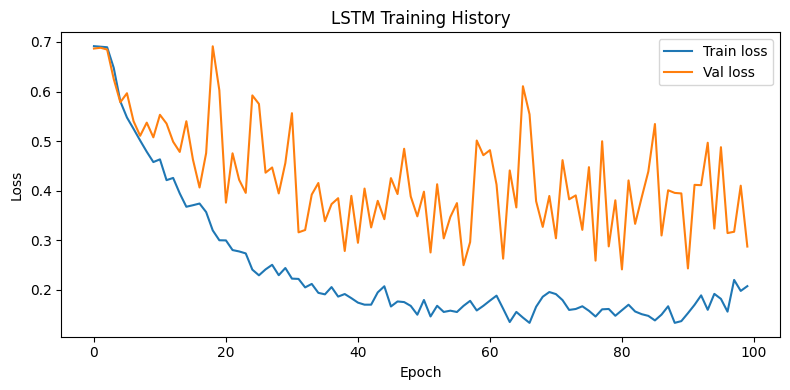

In [ ]:
print(turn_red("Q) Instantiate and train the LSTMClassifier."))
print(turn_red("   Choose hyperparameters for embedding_dim, hidden_size, n_layers, lr, epochs."))
print(turn_red("   Use a weighted CrossEntropyLoss. Plot the training history."))
print(turn_red("   Does the LSTM converge smoothly?"))

############################################# YOUR SOLUTION HERE

import matplotlib.pyplot as plt

set_seed(RANDOM_STATE)


VOCAB_SIZE    = len(vocab)
EMBEDDING_DIM = 32
HIDDEN_SIZE   = 16
N_LAYERS      = 5
LR            = 1e-2
EPOCHS        = 100

lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=N_LAYERS,
    num_classes=2
).to(device)

class_weights_lstm = torch.tensor(cw_lstm, dtype=torch.float32).to(device)
criterion_lstm     = nn.CrossEntropyLoss(weight=class_weights_lstm)
optimizer_lstm     = torch.optim.Adam(lstm_model.parameters(), lr=LR)

lstm_model, history_lstm = run_training(
    lstm_model, train_loader_lstm, val_loader_lstm,
    optimizer_lstm, criterion_lstm,
    epochs=EPOCHS, device=device, model_type="lstm"
)

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history_lstm["train_loss"], label="Train loss")
plt.plot(history_lstm["val_loss"],   label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Training History")
plt.legend(); plt.tight_layout(); plt.show()

# The LSTM doesn't converges smoothly: both train loss decrease steadily but val loss shows spikes and starts divergin from 20th epoch



Q) Evaluate the LSTM on the test set. Report the full classification report.
   Also store predictions as y_pred_lstm for the comparison in Block 05.
              precision    recall  f1-score   support

      benign       0.46      0.82      0.59       243
     malware       0.99      0.96      0.98      6262

    accuracy                           0.96      6505
   macro avg       0.73      0.89      0.78      6505
weighted avg       0.97      0.96      0.96      6505



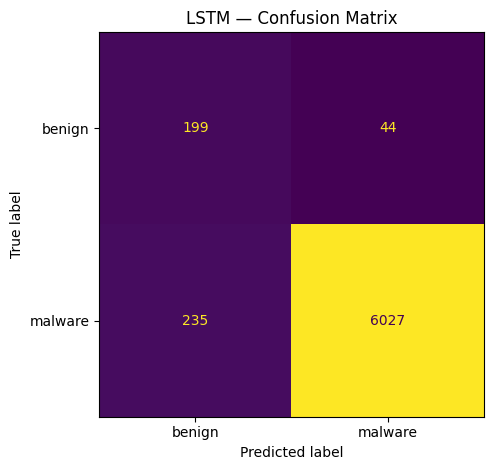

In [40]:
print(turn_red("Q) Evaluate the LSTM on the test set. Report the full classification report."))
print(turn_red("   Also store predictions as y_pred_lstm for the comparison in Block 05."))

############################################# YOUR SOLUTION HERE

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_lstm, y_true_lstm = get_predictions(lstm_model, test_loader_lstm, device, model_type="lstm")

print(classification_report(y_true_lstm, y_pred_lstm, target_names=["benign", "malware"]))

ConfusionMatrixDisplay.from_predictions(
    y_true_lstm, y_pred_lstm,
    display_labels=["benign", "malware"],
    colorbar=False
)
plt.title("LSTM — Confusion Matrix")
plt.tight_layout()
plt.show()


---
## Block 05 — Comparison & Reflection

You have now trained three very different models on the same data:

| Model        | Key idea                             | Discards order? |
|--------------|--------------------------------------|-----------------|
| BoW + RF     | Count-based features, classic ML     | Yes             |
| EmbedderMLP  | Learned token embeddings, mean-pool  | Yes             |
| LSTM         | Learned embeddings + sequential LSTM | No              |

## (OPTIONAL) Reflection Questions

Answer the following questions (as comments in the cell below or in a new
markdown cell):

1. **BoW strength.** BoW discards all order information yet achieves the highest F1. Why might counting API calls — without caring about order — be sufficient for this task? 
What would need to change in the data (dataset size? sequence length? attack complexity?) for the LSTM to outperform BoW?
    - Counting is sufficient because malware identity is encoded in which calls appear, not when. Malicious processes reliably over-use a characteristic set (NtWriteVirtualMemory, LdrLoadDll, etc.) regardless of order — a Random Forest on those frequencies draws clean boundaries. 
    For the LSTM to win, the data would need:
    Longer sequences (500+): multi-stage attack chains (recon → privilege escalation → lateral movement) create temporal dependencies that counts can't capture.
    Polymorphic malware: adversaries that mimic benign frequency distributions but expose themselves through characteristic orderings (e.g. always A then B within N steps).
    More data: LSTMs are sample-hungry; with enough examples the temporal signal becomes reliably learnable.

2. **Evaluation metric.** Accuracy is above 90% for every model, yet F1 scores are much lower. Why?
Given the class imbalance, which metric matters more to a security analyst — precision or recall? Justify your answer in a practical context (what is the cost of a false negative here?).
    - Accuracy is useless here — a classifier that always predicts malware scores 96% without catching a single benign sample. It's dominated by the majority class.
    Recall on malware matters most to a security analyst. The cost asymmetry is stark:
    False negative (malware → benign): threat runs undetected, can exfiltrate, encrypt, propagate. Cost: potentially catastrophic.
    False positive (benign → malware): a clean process is quarantined. Cost: analyst time, minor disruption — recoverable.
    Macro F1 is the honest summary metric; the primary target is malware recall

3. **OOV handling.** There are 3 API calls in the test set that never appeared in training. How does each of your three models deal with them? Which approach is most robust to this kind of distribution shift?
You have now trained three very different models on the same data:

    | Model        | What happens to OOV calls                                               | 
    |--------------|-------------------------------------------------------------------------|
    | BoW + RF     | No feature column exists → zero in that position → silently ignored     | 
    | EmbedderMLP  | Mapped to <UNK> (index 1) → shared learned embedding                    | 
    | LSTM         | Same as EmbedderMLP — <UNK> embedding at that timestep                  |

    Most robust: BoW + RF. It ignores unknowns cleanly. The neural models collapse all OOV calls to the same <UNK> vector, losing any distinction between them — and if <UNK> was rare during training, its embedding is poorly learned and could inject misleading signal.